# 05 - EDA, Visualizations & Business Insights

## Objective
Translate all previous analysis into visual stories and 
actionable business recommendations.

## Charts Produced
1. Churn Status Distribution (with zoomed at-risk view)
2. Behavioral Segment Distribution
3. Inactivity Days Distribution (with threshold markers)
4. Purchase Behavior by Churn Status
5. Activity Metrics by Behavioral Segment
6. Purchase Frequency Distribution by Churn Status
7. Top 10 Users by Total Spend
8. Spend Distribution by Behavioral Segment (Box Plot)

## Key Takeaways
- 92.8% retention rate overall
- At-risk users are financially identical to active users
- Quiet Loyal users represent hidden high value customers
- Intervention window is narrow — only 7 days before full churn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
#set the visual style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size']= 12

#load segmented dataset

df = pd.read_csv(r'F:\Projects\User Retention Study\User Churn Analysis\Data\cleaned\behavioral_segments.csv')

#reconvert dates
df['first_activity'] = pd.to_datetime(df['first_activity'])
df['last_activity'] = pd.to_datetime(df['last_activity'])

#check
print(df.shape)
print(df.columns.tolist())

(1000, 14)
['UserID', 'total_events', 'total_sessions', 'total_purchases', 'total_spend', 'unique_events', 'first_activity', 'last_activity', 'active_days', 'purchase_frequency', 'inactivity_days', 'churn_label', 'activity_level', 'segment']


Text(0.5, 1.02, 'User Churn Status Distribution')

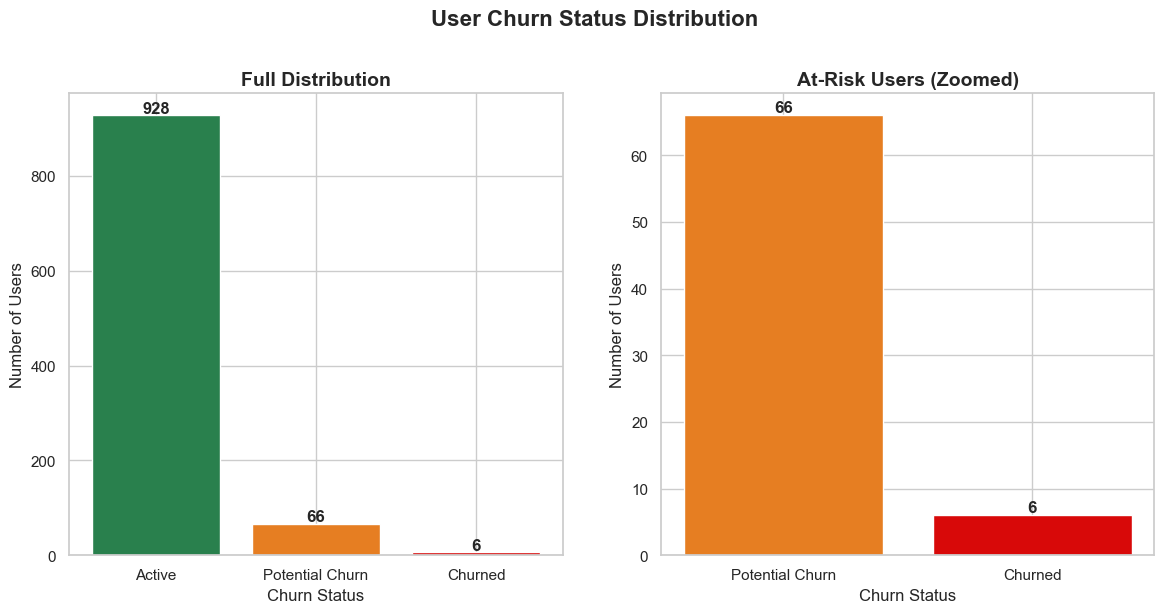

In [ ]:
#Churn Distribution Chart

#Define color for each lable


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Full distribution
bars1 = ax1.bar(
    churn_counts.index,
    churn_counts.values,
    color=['#29804d', '#e67e22', '#d80909']
)

for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f'{int(height)}',
        ha='center',
        fontweight='bold'
    )

ax1.set_title('Full Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Churn Status')
ax1.set_ylabel('Number of Users')

# Chart 2: Zoomed in on at-risk users only
atrisk_order = ['Potential Churn', 'Churned']
atrisk_counts = churn_counts.reindex(atrisk_order)

bars2 = ax2.bar(
    atrisk_counts.index,
    atrisk_counts.values,
    color=['#e67e22', '#d80909']
)

for bar in bars2:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{int(height)}',
        ha='center',
        fontweight='bold'
    )

ax2.set_title('At-Risk Users (Zoomed)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Churn Status')
ax2.set_ylabel('Number of Users')

fig.suptitle('User Churn Status Distribution', fontsize=16, fontweight='bold', y=1.02)

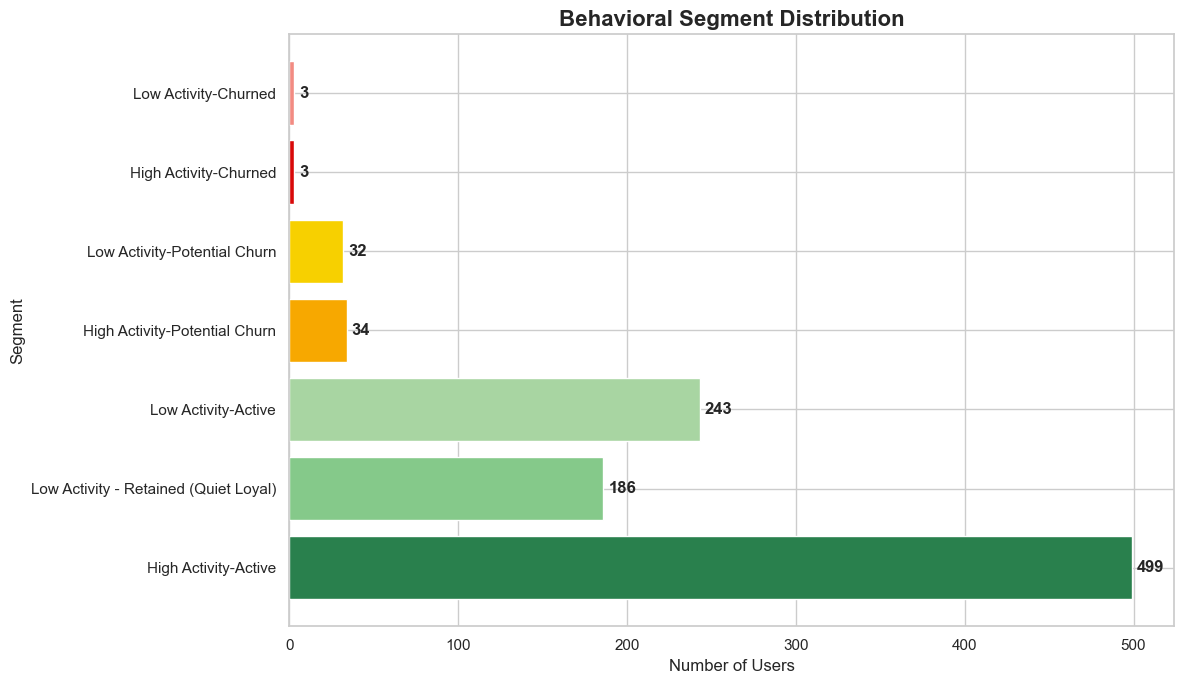

In [ ]:
#Behavioral Segments Chart

#get segment counts in order
segment_order = [
    'High Activity-Active',
    'Low Activity - Retained (Quiet Loyal)',
    'Low Activity-Active',
    'High Activity-Potential Churn',
    'Low Activity-Potential Churn',
    'High Activity-Churned',
    'Low Activity-Churned'
]

segment_counts = df['segment'].value_counts().reindex(segment_order)


#define color per segment
segment_colors =[
     '#29804d',  # High Activity Active - dark green
    '#85c98a',  # Quiet Loyal - light green
    '#a8d5a2',  # Low Activity Active - pale green
    '#f7a800',  # High Activity Potential Churn - dark orange
    '#f7d000',  # Low Activity Potential Churn - light orange
    '#d80909',  # High Activity Churned - dark red
    '#f28b82'   # Low Activity Churned - light red
]

#build chart
fig, ax = plt.subplots(figsize=(12,7))
bars = ax.barh(
    segment_counts.index,
    segment_counts.values,
    color=segment_colors
)

#add count at the end of each of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}' ,
        va='center',
        fontweight='bold'
    )
    
ax.set_title('Behavioral Segment Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Users')
ax.set_ylabel('Segment')

plt.tight_layout()
plt.savefig(r'F:\Projects\User Retention Study\User Churn Analysis\reports\screenshots\behavioral_segments.png', dpi=150, bbox_inches='tight')
plt.show()

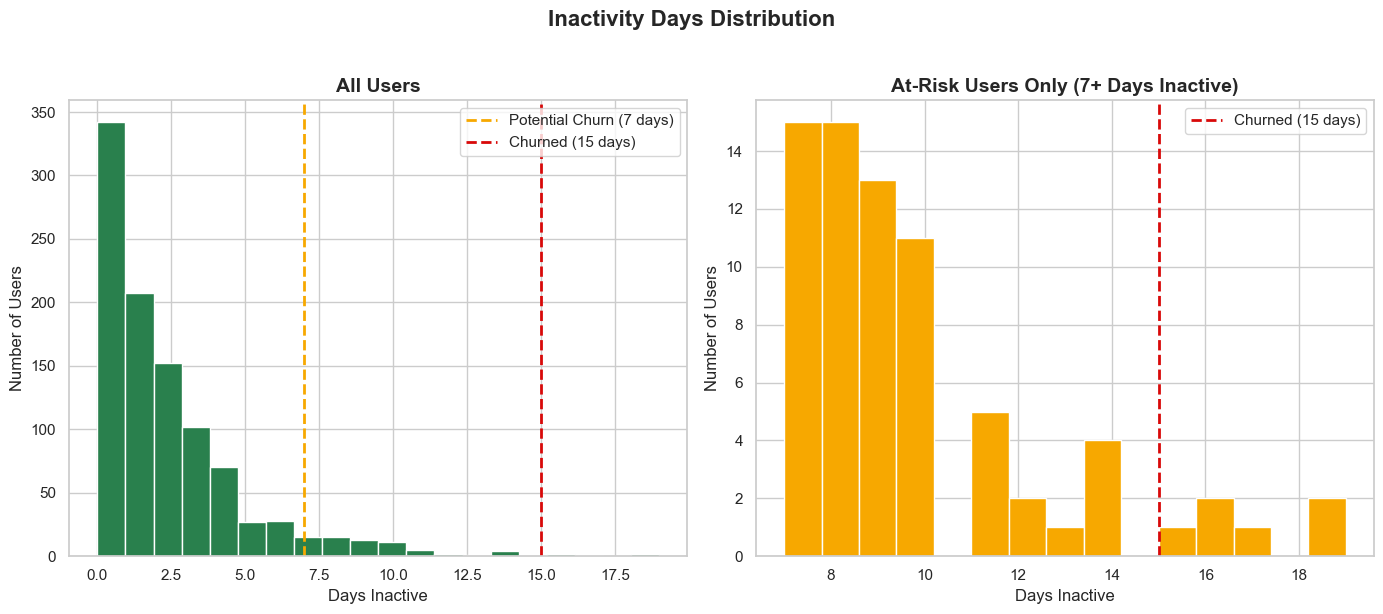

In [ ]:
# Inactivity Days Distribution

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Full distribution
ax1.hist(df['inactivity_days'], bins=20, 
         color='#29804d', edgecolor='white')
ax1.axvline(x=7, color='#f7a800', linewidth=2, 
            linestyle='--', label='Potential Churn (7 days)')
ax1.axvline(x=15, color='#d80909', linewidth=2, 
            linestyle='--', label='Churned (15 days)')
ax1.set_title('All Users', fontsize=14, fontweight='bold')
ax1.set_xlabel('Days Inactive')
ax1.set_ylabel('Number of Users')
ax1.legend()

# Chart 2: Zoomed into at-risk users only (7+ days inactive)
atrisk = df[df['inactivity_days'] >= 7]
ax2.hist(atrisk['inactivity_days'], bins=15,
         color='#f7a800', edgecolor='white')
ax2.axvline(x=15, color='#d80909', linewidth=2,
            linestyle='--', label='Churned (15 days)')
ax2.set_title('At-Risk Users Only (7+ Days Inactive)', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Days Inactive')
ax2.set_ylabel('Number of Users')
ax2.legend()

fig.suptitle('Inactivity Days Distribution', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(r'F:\Projects\User Retention Study\User Churn Analysis\reports\screenshots\inactivity_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()

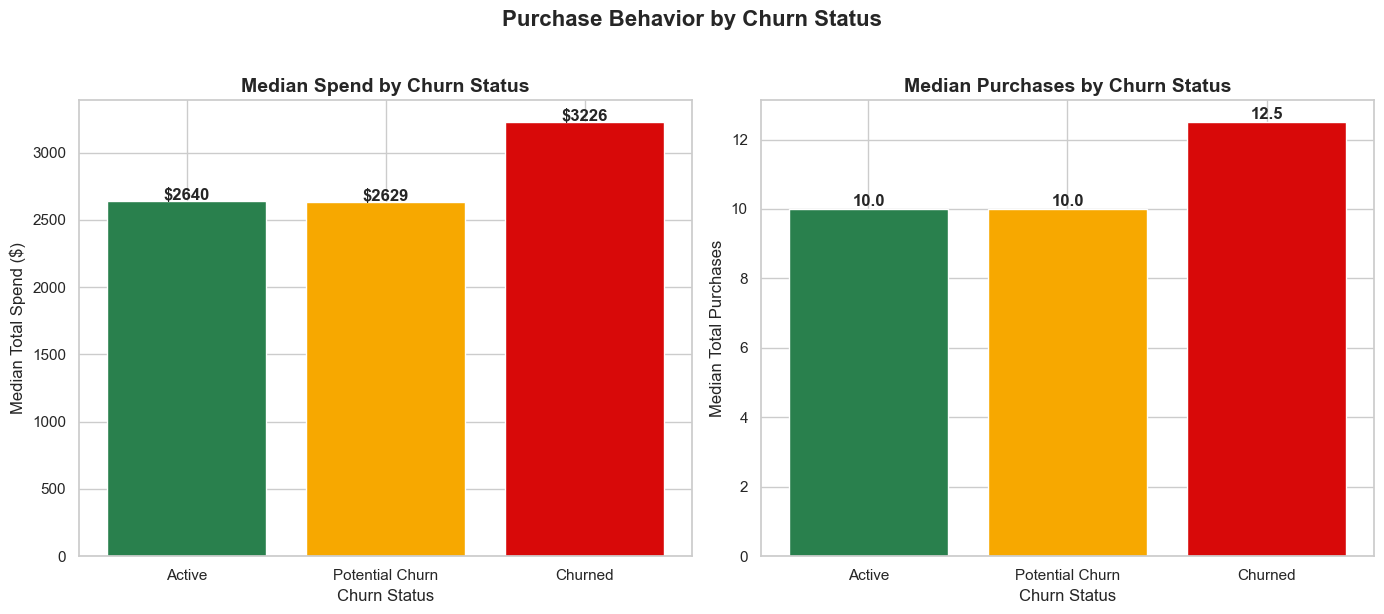

In [ ]:
#Purchase Behavior by Churn Label

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Total spend by churn label
churn_order = ['Active', 'Potential Churn', 'Churned']
colors = ['#29804d', '#f7a800', '#d80909']

spend_by_churn = df.groupby('churn_label')['total_spend'].median().reindex(churn_order)

bars1 = ax1.bar(
    spend_by_churn.index,
    spend_by_churn.values,
    color=colors
)

for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 10,
        f'${height:.0f}',
        ha='center',
        fontweight='bold'
    )

ax1.set_title('Median Spend by Churn Status', fontsize=14, fontweight='bold')
ax1.set_xlabel('Churn Status')
ax1.set_ylabel('Median Total Spend ($)')

# Chart 2: Total purchases by churn label
purchases_by_churn = df.groupby('churn_label')['total_purchases'].median().reindex(churn_order)

bars2 = ax2.bar(
    purchases_by_churn.index,
    purchases_by_churn.values,
    color=colors
)

for bar in bars2:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.1,
        f'{height:.1f}',
        ha='center',
        fontweight='bold'
    )

ax2.set_title('Median Purchases by Churn Status', fontsize=14, fontweight='bold')
ax2.set_xlabel('Churn Status')
ax2.set_ylabel('Median Total Purchases')

fig.suptitle('Purchase Behavior by Churn Status', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(r'F:\Projects\User Retention Study\User Churn Analysis\reports\screenshots\purchase_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

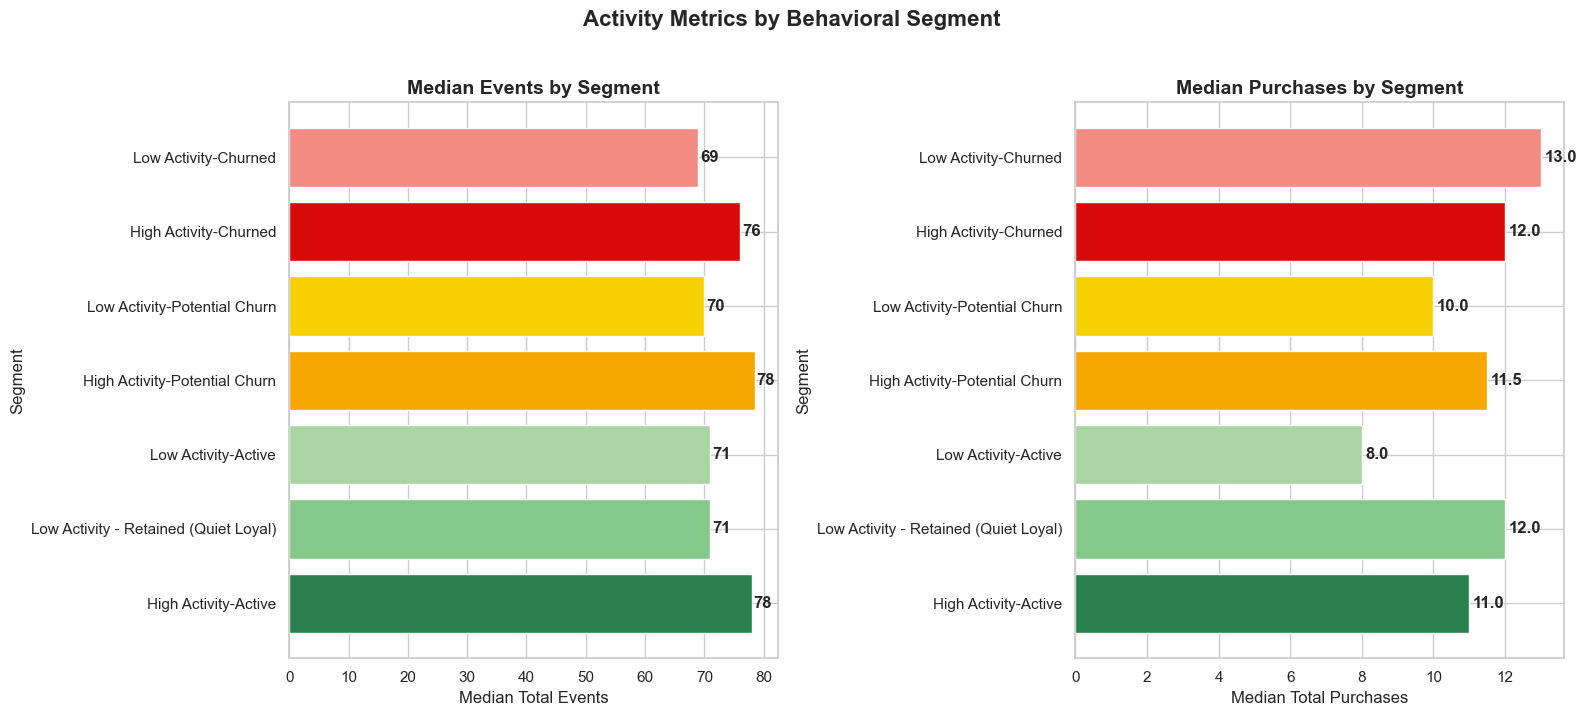

In [20]:
# Activity Metrics by Segment
# Prepare data
segment_order = [
    'High Activity-Active',
    'Low Activity - Retained (Quiet Loyal)',
    'Low Activity-Active',
    'High Activity-Potential Churn',
    'Low Activity-Potential Churn',
    'High Activity-Churned',
    'Low Activity-Churned'
]

segment_stats = df.groupby('segment')[['total_events', 'total_purchases']].median().reindex(segment_order)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1: Median events by segment
colors = [
    '#29804d', '#85c98a', '#a8d5a2',
    '#f7a800', '#f7d000',
    '#d80909', '#f28b82'
]

bars1 = ax1.barh(segment_stats.index, segment_stats['total_events'], color=colors)

for bar in bars1:
    width = bar.get_width()
    ax1.text(width + 0.3, bar.get_y() + bar.get_height()/2,
             f'{width:.0f}', va='center', fontweight='bold')

ax1.set_title('Median Events by Segment', fontsize=14, fontweight='bold')
ax1.set_xlabel('Median Total Events')
ax1.set_ylabel('Segment')

# Chart 2: Median purchases by segment
bars2 = ax2.barh(segment_stats.index, segment_stats['total_purchases'], color=colors)

for bar in bars2:
    width = bar.get_width()
    ax2.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}', va='center', fontweight='bold')

ax2.set_title('Median Purchases by Segment', fontsize=14, fontweight='bold')
ax2.set_xlabel('Median Total Purchases')
ax2.set_ylabel('Segment')

fig.suptitle('Activity Metrics by Behavioral Segment', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(r'F:\Projects\User Retention Study\User Churn Analysis\reports\screenshots\activity_by_segment.png', 
            dpi=150, bbox_inches='tight')
plt.show()

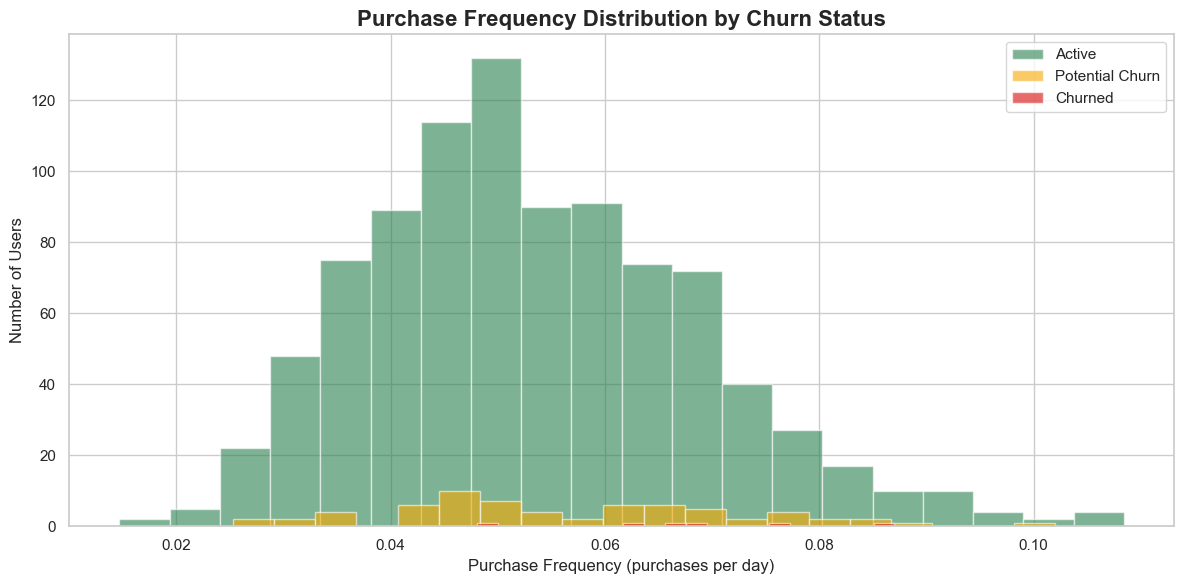

In [21]:
#Purchase Frequency Distribution by Churn Label
fig, ax = plt.subplots(figsize=(12, 6))

churn_order = ['Active', 'Potential Churn', 'Churned']
colors = ['#29804d', '#f7a800', '#d80909']

for churn_label, color in zip(churn_order, colors):
    subset = df[df['churn_label'] == churn_label]['purchase_frequency']
    ax.hist(subset, bins=20, alpha=0.6, 
            color=color, label=churn_label, edgecolor='white')

ax.set_title('Purchase Frequency Distribution by Churn Status', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Purchase Frequency (purchases per day)')
ax.set_ylabel('Number of Users')
ax.legend()

plt.tight_layout()
plt.savefig(r'F:\Projects\User Retention Study\User Churn Analysis\reports\screenshots\purchase_frequency_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()

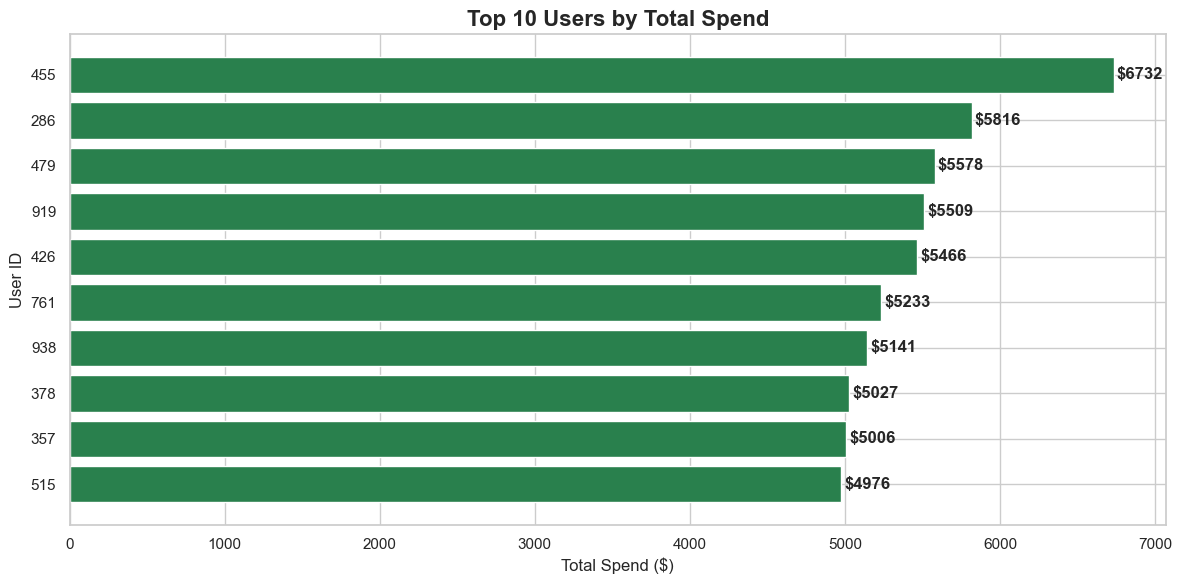

Top 10 spenders segment breakdown:
 UserID  total_spend                               segment
    515  4976.481837 Low Activity - Retained (Quiet Loyal)
    357  5005.741929 Low Activity - Retained (Quiet Loyal)
    378  5027.121856                  High Activity-Active
    938  5140.667290                  High Activity-Active
    761  5232.543710                  High Activity-Active
    426  5465.838376                  High Activity-Active
    919  5508.890384                  High Activity-Active
    479  5578.394072                  High Activity-Active
    286  5815.616394                  High Activity-Active
    455  6732.148219                  High Activity-Active


In [22]:
# Get top 10 spenders with their segment
top10 = df.nlargest(10, 'total_spend')[['UserID', 'total_spend', 'total_purchases', 'segment']]
top10 = top10.sort_values('total_spend')

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    top10['UserID'].astype(str),
    top10['total_spend'],
    color='#29804d'
)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 20, bar.get_y() + bar.get_height()/2,
            f'${width:.0f}', va='center', fontweight='bold')

ax.set_title('Top 10 Users by Total Spend', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Spend ($)')
ax.set_ylabel('User ID')

plt.tight_layout()
plt.savefig(r'F:\Projects\User Retention Study\User Churn Analysis\reports\screenshots\top10_spenders.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print their segments
print("Top 10 spenders segment breakdown:")
print(top10[['UserID', 'total_spend', 'segment']].to_string(index=False))

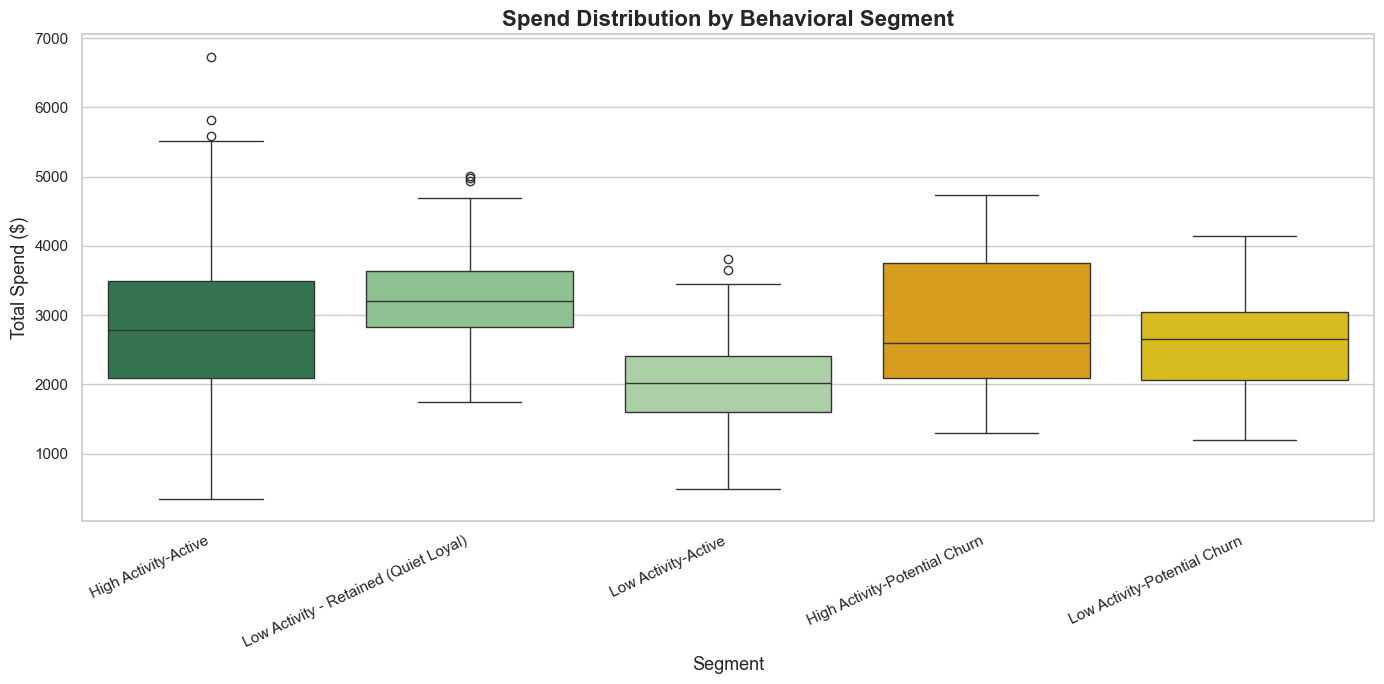

In [25]:
#Monthly Activity Trend
# Filter out small segments for cleaner visual
main_segments = [
    'High Activity-Active',
    'Low Activity - Retained (Quiet Loyal)',
    'Low Activity-Active',
    'High Activity-Potential Churn',
    'Low Activity-Potential Churn'
]

df_filtered = df[df['segment'].isin(main_segments)]

fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#29804d', '#85c98a', '#a8d5a2', '#f7a800', '#f7d000']

sns.boxplot(
    data=df_filtered,
    x='segment',
    y='total_spend',
    order=main_segments,
    hue='segment',
    hue_order=main_segments,
    palette=dict(zip(main_segments, colors)),
    legend=False,
    ax=ax
)

ax.set_title('Spend Distribution by Behavioral Segment',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Segment', fontsize=13)
ax.set_ylabel('Total Spend ($)', fontsize=13)
plt.xticks(rotation=25, ha='right')

plt.tight_layout()
plt.savefig(r'F:\Projects\User Retention Study\User Churn Analysis\reports\screenshots\spend_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()


# Business Insights & Recommendations

## Dataset Summary
- Total Users: 1,000
- Date Range: January 1, 2024 – July 24, 2024
- Total Events: 74,817

---

## Key Finding 1: Platform Retention is Strong
92.8% of users are currently active. The platform is healthy overall.
However, 72 users (7.2%) show signs of disengagement — representing
an early intervention opportunity before revenue impact occurs.

## Key Finding 2: At-Risk Users Are Financially Invisible
Users labeled Potential Churn show identical spend ($2,629) and
purchase frequency (10.0) compared to Active users ($2,640, 10.0).
This means traditional spend-based monitoring would completely miss
these users. Only behavioral inactivity tracking can catch them early.

## Key Finding 3: Quiet Loyal Users Are Hidden High-Value Customers
186 users (18.6%) visit infrequently but purchase consistently above
the median frequency. Two of the top 10 spenders in the entire
platform are Quiet Loyal users — spending nearly $5,000 each.
These users are easy to overlook but dangerous to lose.

## Key Finding 4: High Activity Potential Churn is the Most Urgent Segment
34 users are highly engaged but showing early churn signals.
Their spend reaches up to $4,600 and purchases average 11.5 —
nearly identical to your best users. Losing these users would
have immediate revenue impact.

## Key Finding 5: Inactivity Threshold Adjustment Was Data-Driven
Original framework used 25/30 day thresholds. Dataset analysis
revealed maximum inactivity of only 19 days — requiring adjustment
to 7/14 days. This reflects a core analytical principle: thresholds
must be grounded in actual data behavior, not assumptions.

---

## Recommendations

### Immediate Actions (This Week)
1. **Target the 34 High Activity Potential Churn users first.**
   These are your highest value at-risk users. Send personalized
   re-engagement campaigns before they cross the 15-day threshold.

2. **Do not ignore the 32 Low Activity Potential Churn users.**
   Lower priority than above but still worth a lightweight
   automated email nudge.

### Short Term Actions (This Month)
3. **Protect your 186 Quiet Loyal users.**
   These users don't need frequent contact — they're already buying.
   Focus on ensuring their experience remains frictionless.
   A loyalty reward for milestone purchases could reinforce behavior.

4. **Investigate the 243 Low Activity Active users.**
   They're retained but purchasing below average (8.0 purchases vs
   platform median of 10.0). These users have growth potential —
   product recommendation emails could increase their purchase frequency.

### Long Term Actions
5. **Build an automated early warning system.**
   Flag any user crossing 7 days of inactivity automatically.
   This analysis shows that by day 15 they are already churned —
   the intervention window is narrow.

6. **Monitor top spenders proactively.**
   8 of the top 10 spenders are currently safe (High Activity Active)
   but proactive VIP treatment ensures they stay that way.

---

## Analytical Limitations
- Dataset is synthetically generated — real platforms show higher
  variance in behavior and typically higher churn rates (20-40%)
- Churned segment contains only 6 users — insufficient for
  statistically reliable conclusions about churned user behavior
- No demographic or product category data available for deeper
  segmentation analysis